# Regression Model For Predicting Taxi Fare Amount

* Here we will follow the `PACE` framework to build a regression model to predict taxi fare amount based on various features such as pickup and dropoff locations, time of day, and passenger count.

## PACE: 
1. Plan
2. Analyze
3. Construct
4. Execute

### Stage #1. Plan 
* Define the problem: Predict taxi fare amount based on various features.
* Identify the data sources: NYC Taxi and Limousine Commission (TLC) Trip Record Data
* Determine the evaluation metrics: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE)
* Outline the steps to build the model: Data collection, data preprocessing, feature engineering, model selection, training, evaluation, and deployment.
* Set up the environment: Python, Jupyter Notebook, libraries (pandas, numpy, scikit-learn, matplotlib, seaborn)
* Establish a timeline: 2 weeks for data collection and preprocessing, 1 week for model training and evaluation, 1 week for deployment.
 

## Importing Libraries and Loading Data

In [1]:
# Imports
# Packages for numeric and data manipulation
import numpy as np
import pandas as pd

# Packages for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Packages for data conversions for calculating trip duration and distance
from datetime import datetime
from datetime import date
from datetime import timedelta

# Packages for OLS, MLR, Confusion matrix, MAE, MSE, R2 calculations
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics      # For confusion matrix and other metrics
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load the dataset
df = pd.read_csv('./dataset/2017_Yellow_Taxi_Trip_Data.csv')  

# Display the first few rows of the dataframe
df.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80


In [3]:
# Display the dataframe shape 
print(df.shape)

# Display the basic information about the dataframe
df.info()

(22699, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  flo

In [4]:
# Check for duplicate values
duplicate_rows = df.duplicated()
print(f"Number of duplicate rows: {duplicate_rows.sum()}")

Number of duplicate rows: 0


In [5]:
# Chck for missing values
missing_values = df.isna().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Unnamed: 0               0
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
dtype: int64


## Outcomes of Plan Stage
* We have successfully planned the project using the PACE framework.
* There are total `22699` rows and `18` columns in the dataset.
* The dataset contains various features such as pickup and dropoff datetime, passenger count, trip distance, fare amount, payment type, and more.
* There are no missing values in the dataset.
* There are `0` duplicate rows in the dataset.
* The dataset contains a mix of numerical and categorical features.
* The target variable is `fare_amount`, which we will predict using the other features in the dataset.
* The dataset is ready for further analysis and model building.
* We will proceed to the next stages of the PACE framework: Analyze, Construct, and Execute.

---

## Stage #2: Analyze
* In this stage, we will perform exploratory data analysis (EDA) to understand the dataset better. We will visualize the relationships between different features and the target variable (fare amount). We will also check for any outliers or anomalies in the data that may affect the model's performance.

In [6]:
# Descriptive Statistics of Numerical Features
df.describe()

,Unnamed: 0,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,2.269900e+04,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000
mean,5.675849e+07,1.556236,1.642319,2.913313,1.043394,162.412353,161.527997,1.336887,13.026629,0.333275,0.497445,1.835781,0.312542,0.299551,16.310502
std,3.274493e+07,0.496838,1.285231,3.653171,0.708391,66.633373,70.139691,0.496211,13.243791,0.463097,0.039465,2.800626,1.399212,0.015673,16.097295
min,1.212700e+04,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-120.000000,-1.000000,-0.500000,0.000000,0.000000,-0.300000,-120.300000
25%,2.852056e+07,1.000000,1.000000,0.990000,1.000000,114.000000,112.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.750000
50%,5.673150e+07,2.000000,1.000000,1.610000,1.000000,162.000000,162.000000,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.800000
75%,8.537452e+07,2.000000,2.000000,3.060000,1.000000,233.000000,233.000000,2.000000,14.500000,0.500000,0.500000,2.450000,0.000000,0.300000,17.800000
max,1.134863e+08,2.000000,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,999.990000,4.500000,0.500000,200.000000,19.100000,0.300000,1200.290000


* Here we noticed that there are some outliers in `tip_amount` as tip_amount is `200` while total_amount is `1200`.
* Next mta_tax remains about seems to be constant throughout the data.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  float64
 15  to

* We will convert `pickup_datetime` and `dropoff_datetime` to datetime format and extract useful features such as hour of day, day of week, and month.

In [8]:
# Check the format of the data
df['tpep_pickup_datetime'][0]

'03/25/2017 8:55:43 AM'

In [9]:
# Convert datetime columns to datetime
# Display data types of `tpep_pickup_datetime`, `tpep_dropoff_datetime`
print('Data type of tpep_pickup_datetime:', df['tpep_pickup_datetime'].dtype)
print('Data type of tpep_dropoff_datetime:', df['tpep_dropoff_datetime'].dtype)

# Convert `tpep_pickup_datetime` to datetime format
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'], format='%m/%d/%Y %I:%M:%S %p')

# Convert `tpep_dropoff_datetime` to datetime format
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'], format='%m/%d/%Y %I:%M:%S %p')

# Display data types of `tpep_pickup_datetime`, `tpep_dropoff_datetime`
print('Data type of tpep_pickup_datetime:', df['tpep_pickup_datetime'].dtype)
print('Data type of tpep_dropoff_datetime:', df['tpep_dropoff_datetime'].dtype)

df.head(3)

Data type of tpep_pickup_datetime: object
Data type of tpep_dropoff_datetime: object
Data type of tpep_pickup_datetime: datetime64[ns]
Data type of tpep_dropoff_datetime: datetime64[ns]


,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75


* Create a new column called `duration` that represents the total number of minutes that each taxi ride took.

In [10]:
# Create `duration` column
df['duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime'])/np.timedelta64(1,'m')
df.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56,14.066667
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80,26.500000
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75,7.200000
3,38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69,30.250000
4,30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80,16.716667


### Outliers
* Notice that many of the columns in the dataset will not be used in our regression model to predict fare amount.
* The most important columns we will focus on are:
  - `passenger_count`
  - `trip_distance`
  - `payment_type`
  - `fare_amount` (target variable)
  - `duration` (newly created column)


Call `df.info()` to inspect the columns and decide which ones to check for outliers.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0             22699 non-null  int64         
 1   VendorID               22699 non-null  int64         
 2   tpep_pickup_datetime   22699 non-null  datetime64[ns]
 3   tpep_dropoff_datetime  22699 non-null  datetime64[ns]
 4   passenger_count        22699 non-null  int64         
 5   trip_distance          22699 non-null  float64       
 6   RatecodeID             22699 non-null  int64         
 7   store_and_fwd_flag     22699 non-null  object        
 8   PULocationID           22699 non-null  int64         
 9   DOLocationID           22699 non-null  int64         
 10  payment_type           22699 non-null  int64         
 11  fare_amount            22699 non-null  float64       
 12  extra                  22699 non-null  float64       
 13  m

* We will plot a boxplot to visualize the distribution of `fare_amount`, `trip_distance` and `duration` for outliers.

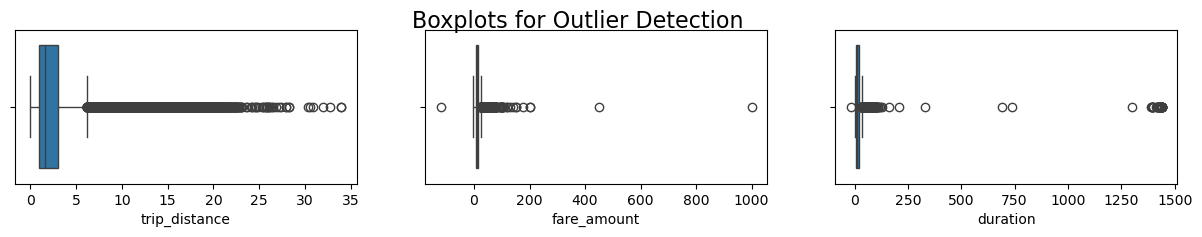

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 2))
fig.suptitle('Boxplots for Outlier Detection', fontsize=16)
sns.boxplot(ax=axes[0], data=df, x=df['trip_distance'])
sns.boxplot(ax=axes[1], data=df, x=df['fare_amount'])
sns.boxplot(ax=axes[2], data=df, x=df['duration'])
plt.show();

## Outliers (Outcome)
* We can see potential outliers in `trip_distance`, `fare_amount`, and `duration` based on the boxplots.
1. It's 30 miles from the southern tip of Staten Island to the northern end of Manhattan and that's in a straight line. With this knowledge and the distribution of the values in this column, it's reasonable to leave these values alone and not alter them. However, the values for `fare_amount` and `duration` definitely seem to have problematic outliers on the higher end.

2. Probably not for the latter two, but for `trip_distance` it might be okay.
* We will need to handle these outliers in the next stage (Construct) to ensure they do not negatively impact our regression model's performance.

In [13]:
# Calculate Q1 and Q3 for `trip_distance`, `fare_amount`, and `duration`
Q1_trip_distance = df['trip_distance'].quantile(0.25)
Q3_trip_distance = df['trip_distance'].quantile(0.75)
IQR_trip_distance = Q3_trip_distance - Q1_trip_distance

Q1_fare_amount = df['fare_amount'].quantile(0.25)
Q3_fare_amount = df['fare_amount'].quantile(0.75)
IQR_fare_amount = Q3_fare_amount - Q1_fare_amount

Q1_duration = df['duration'].quantile(0.25)
Q3_duration = df['duration'].quantile(0.75)
IQR_duration = Q3_duration - Q1_duration

# Define outlier boundaries
lower_bound_trip_distance = Q1_trip_distance - 1.5 * IQR_trip_distance
upper_bound_trip_distance = Q3_trip_distance + 1.5 * IQR_trip_distance

lower_bound_fare_amount = Q1_fare_amount - 1.5 * IQR_fare_amount
upper_bound_fare_amount = Q3_fare_amount + 1.5 * IQR_fare_amount

lower_bound_duration = Q1_duration - 1.5 * IQR_duration
upper_bound_duration = Q3_duration + 1.5 * IQR_duration

# Display the outlier boundaries
print(f"Trip Distance Outlier Boundaries: {lower_bound_trip_distance} to {upper_bound_trip_distance}")
print(f"Fare Amount Outlier Boundaries: {lower_bound_fare_amount} to {upper_bound_fare_amount}")
print(f"Duration Outlier Boundaries: {lower_bound_duration} to {upper_bound_duration}")

# Remove outliers from the dataframe
df = df[(df['trip_distance'] >= lower_bound_trip_distance) & (df['trip_distance'] <= upper_bound_trip_distance)]
df = df[(df['fare_amount'] >= lower_bound_fare_amount) & (df['fare_amount'] <= upper_bound_fare_amount)]
df = df[(df['duration'] >= lower_bound_duration) & (df['duration'] <= upper_bound_duration)]

# Display the shape of the dataframe after outlier removal
print(f"Dataframe shape after outlier removal: {df.shape}")



Trip Distance Outlier Boundaries: -2.115 to 6.165000000000001
Fare Amount Outlier Boundaries: -5.5 to 26.5
Duration Outlier Boundaries: -10.949999999999998 to 35.983333333333334
Dataframe shape after outlier removal: (19849, 19)


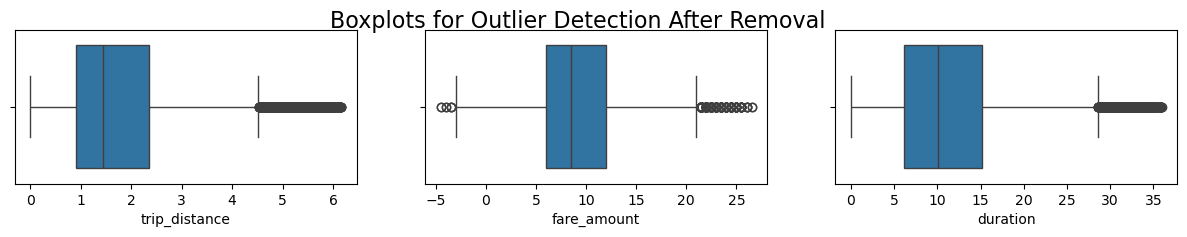

In [14]:
# Now again craete boxplots to confirm that outliers have been removed
fig, axes = plt.subplots(1, 3, figsize=(15, 2))
fig.suptitle('Boxplots for Outlier Detection After Removal', fontsize=16)
sns.boxplot(ax=axes[0], data=df, x=df['trip_distance'])
sns.boxplot(ax=axes[1], data=df, x=df['fare_amount'])
sns.boxplot(ax=axes[2], data=df, x=df['duration'])
plt.show();

In [15]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 19849 entries, 0 to 22698
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0             19849 non-null  int64         
 1   VendorID               19849 non-null  int64         
 2   tpep_pickup_datetime   19849 non-null  datetime64[ns]
 3   tpep_dropoff_datetime  19849 non-null  datetime64[ns]
 4   passenger_count        19849 non-null  int64         
 5   trip_distance          19849 non-null  float64       
 6   RatecodeID             19849 non-null  int64         
 7   store_and_fwd_flag     19849 non-null  object        
 8   PULocationID           19849 non-null  int64         
 9   DOLocationID           19849 non-null  int64         
 10  payment_type           19849 non-null  int64         
 11  fare_amount            19849 non-null  float64       
 12  extra                  19849 non-null  float64       
 13  mta_ta

## Feature Engineering
* We will create new features based on the existing columns to improve the model's performance.
* By creating a helper column called pickup_dropoff, which contains the unique combination of pickup and dropoff location IDs for each row.
* Now, use a groupby() statement to group each row by the new pickup_dropoff column, compute the mean, and capture the values only in the trip_distance column. Assign the results to a variable named grouped.
* We will calculate the trip duration in minutes and create a new column called `duration`.
* We will calculate the trip speed in miles per hour and create a new column called `speed_mph`.
* We will extract the hour of day, day of week, and month from the pickup datetime and create new columns for each.
* We will encode categorical variables such as `payment_type` using one-hot encoding.
* We will normalize numerical features such as `trip_distance`, `duration`, and `speed_mph` using Min-Max scaling.
* We will drop unnecessary columns that are not relevant to the model such as `vendor_id`, `store_and_fwd_flag`, `pickup_datetime`, `dropoff_datetime`, `rate_code_id`, `extra`, `mta_tax`, `tip_amount`, `tolls_amount`, and `total_amount`.
* After feature engineering, we will have a clean and well-structured dataset ready for model training.
  

In [16]:
# Create `pickup_dropoff` column
df['pickup_dropoff'] = df['PULocationID'].astype(str) + '_' + df['DOLocationID'].astype(str)
df['pickup_dropoff'].head(2)

0    100_231
1     186_43
Name: pickup_dropoff, dtype: object

In [17]:
# Now, use a groupby() statement to group each row by the new pickup_dropoff column, compute the mean, 
# and capture the values only in the trip_distance column. Assign the results to a variable named grouped.
grouped = df.groupby('pickup_dropoff').mean(numeric_only=True)[['trip_distance']]
grouped[:5]

,trip_distance
pickup_dropoff,
100_100,0.3775
100_107,1.1800
100_113,2.0240
100_114,1.9400
100_12,4.5500


In [18]:
# 1. Convert `grouped` to a dictionary
grouped_dict = grouped.to_dict()

# 2. Reassign to only contain the inner dictionary
grouped_dict = grouped_dict['trip_distance']

In [19]:
# 1. Create a mean_distance column that is a copy of the pickup_dropoff helper column
df['mean_distance'] = df['pickup_dropoff']

# 2. Map `grouped_dict` to the `mean_distance` column
df['mean_distance'] = df['mean_distance'].map(grouped_dict)

# Confirm that it worked
df[(df['PULocationID']==100) & (df['DOLocationID']==231)][['mean_distance']]

,mean_distance
0,3.406
4909,3.406
16636,3.406
19761,3.406
20581,3.406


#### Create `mean_duration` column

Repeat the process used to create the `mean_distance` column to create a `mean_duration` column.

In [20]:
grouped = df.groupby('pickup_dropoff').mean(numeric_only=True)[['duration']]
grouped

# Create a dictionary where keys are unique pickup_dropoffs and values are
# mean trip duration for all trips with those pickup_dropoff combos
grouped_dict = grouped.to_dict()
grouped_dict = grouped_dict['duration']

df['mean_duration'] = df['pickup_dropoff']
df['mean_duration'] = df['mean_duration'].map(grouped_dict)

# Confirm that it worked
df[(df['PULocationID']==100) & (df['DOLocationID']==231)][['mean_duration']]

,mean_duration
0,17.91
4909,17.91
16636,17.91
19761,17.91
20581,17.91


#### Create `day` and `month` columns

Create two new columns, `day` (name of day) and `month` (name of month) by extracting the relevant information from the `tpep_pickup_datetime` column.

In [21]:
# Create 'day' Column
df['day'] = df['tpep_pickup_datetime'].dt.day_name().str.lower()

# Create 'month' Column
df['month'] = df['tpep_pickup_datetime'].dt.strftime('%b').str.lower()

#### Create `rush_hour` column

Define rush hour as:
* Any weekday (not Saturday or Sunday) AND
* Either from 06:00&ndash;10:00 or from 16:00&ndash;20:00

Create a binary `rush_hour` column that contains a 1 if the ride was during rush hour and a 0 if it was not.

In [22]:
# Create a 'rush_hour' Column
df['rush_hour'] = df['tpep_pickup_datetime'].dt.hour

# If day is Saturday or Sunday, impute 0 in `rush_hour` column
df.loc[df['day'].isin(['saturday', 'sunday']), 'rush_hour'] = 0

In [23]:
# Example: If rush hour is 8-10 AM and 4-7 PM on weekdays
df['rush_hour'] = 0  # Default to 0
mask = (df.day != 'saturday') & (df.day != 'sunday') & \
((df.tpep_pickup_datetime.dt.hour.between(8, 10)) | (df.tpep_pickup_datetime.dt.hour.between(16, 19)))

df.loc[mask, 'rush_hour'] = 1

In [24]:
df.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,tolls_amount,improvement_surcharge,total_amount,duration,pickup_dropoff,mean_distance,mean_duration,day,month,rush_hour
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,...,0.0,0.3,16.56,14.066667,100_231,3.406000,17.910000,saturday,mar,0
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,...,0.0,0.3,20.80,26.500000,186_43,3.160000,22.054167,tuesday,apr,0
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,...,0.0,0.3,8.75,7.200000,262_236,0.881429,7.250000,friday,dec,0
3,38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,...,0.0,0.3,27.69,30.250000,188_97,3.700000,30.250000,sunday,may,0
4,30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,N,4,112,...,0.0,0.3,17.80,16.716667,4_112,4.435000,14.616667,saturday,apr,0


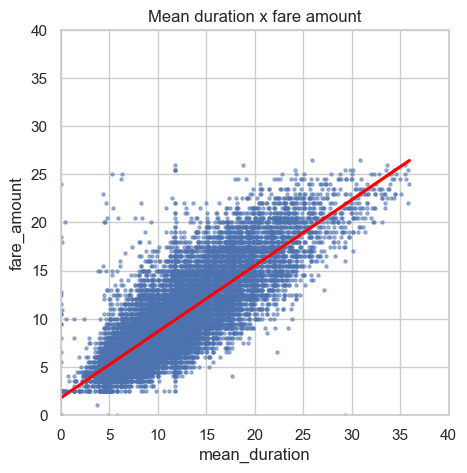

In [25]:
# Create a scatter plot of duration and trip_distance, with a line of best fit
sns.set(style='whitegrid')
f = plt.figure()
f.set_figwidth(5)
f.set_figheight(5)
sns.regplot(x=df['mean_duration'], y=df['fare_amount'],
            scatter_kws={'alpha':0.5, 's':5},
            line_kws={'color':'red'})
plt.ylim(0, 40)
plt.xlim(0, 40)
plt.title('Mean duration x fare amount')
plt.show()

“The axis limits were adjusted to match the data distribution, resulting in a clearer visualization of the regression line and relationship between mean duration and fare amount.”

In [26]:
df[df['fare_amount'] > 50]['fare_amount'].value_counts().head()

Series([], Name: count, dtype: int64)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19849 entries, 0 to 22698
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0             19849 non-null  int64         
 1   VendorID               19849 non-null  int64         
 2   tpep_pickup_datetime   19849 non-null  datetime64[ns]
 3   tpep_dropoff_datetime  19849 non-null  datetime64[ns]
 4   passenger_count        19849 non-null  int64         
 5   trip_distance          19849 non-null  float64       
 6   RatecodeID             19849 non-null  int64         
 7   store_and_fwd_flag     19849 non-null  object        
 8   PULocationID           19849 non-null  int64         
 9   DOLocationID           19849 non-null  int64         
 10  payment_type           19849 non-null  int64         
 11  fare_amount            19849 non-null  float64       
 12  extra                  19849 non-null  float64       
 13  mta_ta

In [28]:
df2 = df.copy()

df2 = df2.drop(['Unnamed: 0', 'tpep_dropoff_datetime', 'tpep_pickup_datetime',
               'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID',
               'payment_type', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
               'total_amount', 'tpep_dropoff_datetime', 'tpep_pickup_datetime', 'duration',
               'pickup_dropoff', 'day', 'month'
               ], axis=1)

df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19849 entries, 0 to 22698
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   VendorID         19849 non-null  int64  
 1   passenger_count  19849 non-null  int64  
 2   fare_amount      19849 non-null  float64
 3   mean_distance    19849 non-null  float64
 4   mean_duration    19849 non-null  float64
 5   rush_hour        19849 non-null  int64  
dtypes: float64(3), int64(3)
memory usage: 1.1 MB


Create a pairplot to visualize pairwise relationships between `fare_amount`, `mean_duration`, and `mean_distance`.

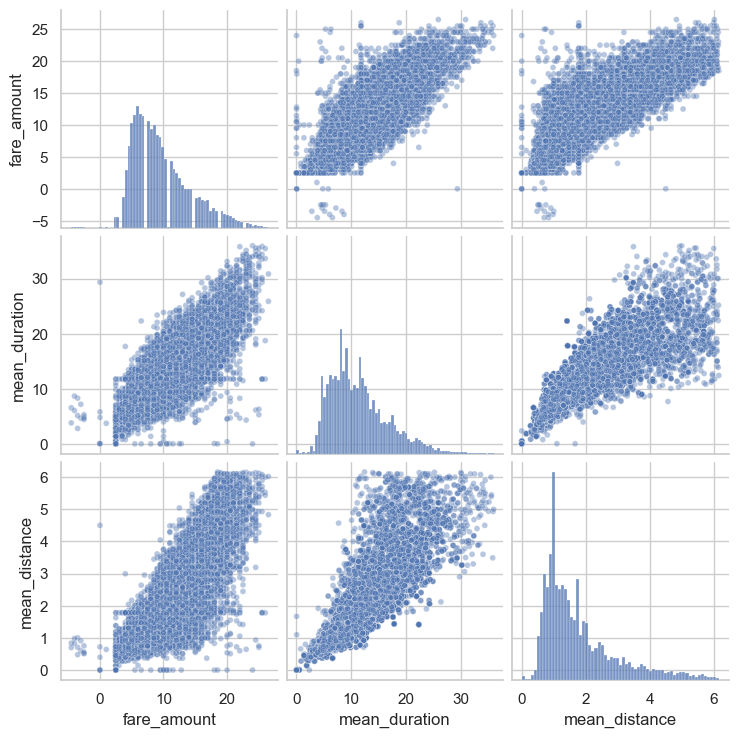

In [29]:
# Create a pairplot to visualize pairwise relationships between variables in the data
### YOUR CODE HERE ###

sns.pairplot(df2[['fare_amount', 'mean_duration', 'mean_distance']],
             plot_kws={'alpha':0.4, 'size':5},
             );

* These visualizations will help us understand the relationships between these features and the target variable (fare amount).

## Stage #3: Construct
* In this stage, we will build and train the regression model using the preprocessed dataset from

### Split data into outcome variable and features
Set your X and y variables. X represents the features and y represents the outcome (target) variable.

In [30]:
# Remove the target column from the features
X = df2.drop(columns=['fare_amount'])

# Set y variable
y = df2[['fare_amount']]

# Display first few rows
X.head()

,VendorID,passenger_count,mean_distance,mean_duration,rush_hour
0,2,6,3.406000,17.910000,0
1,1,1,3.160000,22.054167,0
2,1,1,0.881429,7.250000,0
3,2,1,3.700000,30.250000,0
4,2,1,4.435000,14.616667,0


* Dummy encode categorical variables
  * Convert VendorID to string
  * Dummy encode categorical variables

In [31]:
# Convert VendorID to string
X['VendorID'] = X['VendorID'].astype(str)

# Get dummies
X = pd.get_dummies(X, drop_first=True)
X.head()

,passenger_count,mean_distance,mean_duration,rush_hour,VendorID_2
0,6,3.406000,17.910000,0,True
1,1,3.160000,22.054167,0,False
2,1,0.881429,7.250000,0,False
3,1,3.700000,30.250000,0,True
4,1,4.435000,14.616667,0,True


In [32]:
print(X.dtypes)

passenger_count      int64
mean_distance      float64
mean_duration      float64
rush_hour            int64
VendorID_2            bool
dtype: object


### Split data into training and test sets

Create training and testing sets. The test set should contain 20% of the total samples. Set `random_state=0`.

In [33]:
# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Standardize the data

Use `StandardScaler()`, `fit()`, and `transform()` to standardize the `X_train` variables. Assign the results to a variable called `X_train_scaled`.

In [34]:
# Standardize the X variables
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
print('X_train scaled:', X_train_scaled)

X_train scaled: [[ 1.05238256 -0.86480341 -1.1152307  -0.63110352  0.89781607]
 [-0.49922214 -0.19413276  0.4544179   1.5845261  -1.11381387]
 [ 1.05238256 -0.38002    -0.09262697 -0.63110352  0.89781607]
 ...
 [-0.49922214  0.58411718  1.00284365 -0.63110352  0.89781607]
 [-0.49922214  1.61031868  0.0830195  -0.63110352 -1.11381387]
 [-0.49922214 -0.7081762  -0.42456568 -0.63110352  0.89781607]]


### Fit the model

Instantiate your model and fit it to the training data.

In [35]:
# Fit your model to the training data
lr=LinearRegression()
lr.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Stage #4: Evaluate Model
#### Train Data
Evaluate model performance by calculating the residual sum of squares and the explained variance score (R^2). Calculate the Mean Absolute Error, Mean Squared Error, and the Root Mean Squared Error.

In [36]:
# Evaluate the model performance on the training data
r_sq = lr.score(X_train_scaled, y_train)
print('Coefficient of determination:', r_sq)
y_pred_train = lr.predict(X_train_scaled)
print('R^2:', r2_score(y_train, y_pred_train))
print('MAE:', mean_absolute_error(y_train, y_pred_train))
print('MSE:', mean_squared_error(y_train, y_pred_train))
print('RMSE:',np.sqrt(mean_squared_error(y_train, y_pred_train)))

Coefficient of determination: 0.7476508285335224
R^2: 0.7476508285335224
MAE: 1.6165996434281622
MSE: 5.028657968360071
RMSE: 2.2424669380751348


## Executive Summary: Business Impact & Model Performance

The goal of this project was to develop a linear regression model to predict taxi fare amounts, providing more transparent pricing for riders and better earning estimates for drivers.

### Key Model Performance Metrics:

**R² (Coefficient of Determination): 0.748**

This indicates that approximately 75% of the variation in taxi fares is explained by our model’s features (such as trip distance, time of day, and pickup location).

**MAE (Mean Absolute Error): 1.61**

On average, the model's predictions are within $1.62 of the actual fare.

### Business Implications:

**1. Reliability:** An MAE of $1.62 is highly functional for a "fare estimator" tool, offering passengers a dependable price range before they book a trip.

**2. Predictability:** Explaining 75% of price variance allows the business to identify the most significant drivers of cost, which can be used to optimize surge pricing or driver incentives during peak hours.

**3. Model Limitations:** While the model is strong, the remaining 25% of variance suggests that factors like unexpected traffic delays or specific tolls (not captured in the current dataset) could be explored in future iterations to further improve accuracy.